<a href="https://colab.research.google.com/github/Salome-06/Estadistica/blob/main/Taller_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. 10 Puntos En un estudio sobre rendimiento académico se compararon las calificaciones finales de
estudiantes asignados a tres métodos de enseñanza:
Método A (nA = 12): 78, 80, 76, 82, 79, 81, 77, 80, 83, 79, 78, 80.
Método B (nB = 12): 85, 88, 84, 87, 86, 89, 90, 85, 87, 88, 86, 87.
Método C (nC = 12): 70, 72, 68, 71, 69, 73, 70, 72, 71, 70, 69, 71.



Aplique la prueba ANOVA de una vía con α = 0,01 y determine si existen diferencias significativas
entre los métodos de enseñanza.

DATOS ORIGINALES:
   Metodo  Calificacion
0       A            78
1       A            80
2       A            76
3       A            82
4       A            79
5       A            81
6       A            77
7       A            80
8       A            83
9       A            79
10      A            78
11      A            80
12      B            85
13      B            88
14      B            84
15      B            87
16      B            86
17      B            89
18      B            90
19      B            85
20      B            87
21      B            88
22      B            86
23      B            87
24      C            70
25      C            72
26      C            68
27      C            71
28      C            69
29      C            73
30      C            70
31      C            72
32      C            71
33      C            70
34      C            69
35      C            71

Medias por Método:
  A: 79.4167
  B: 86.8333
  C: 70.5000
Media Global: 78.9167

TABLA ANOVA 

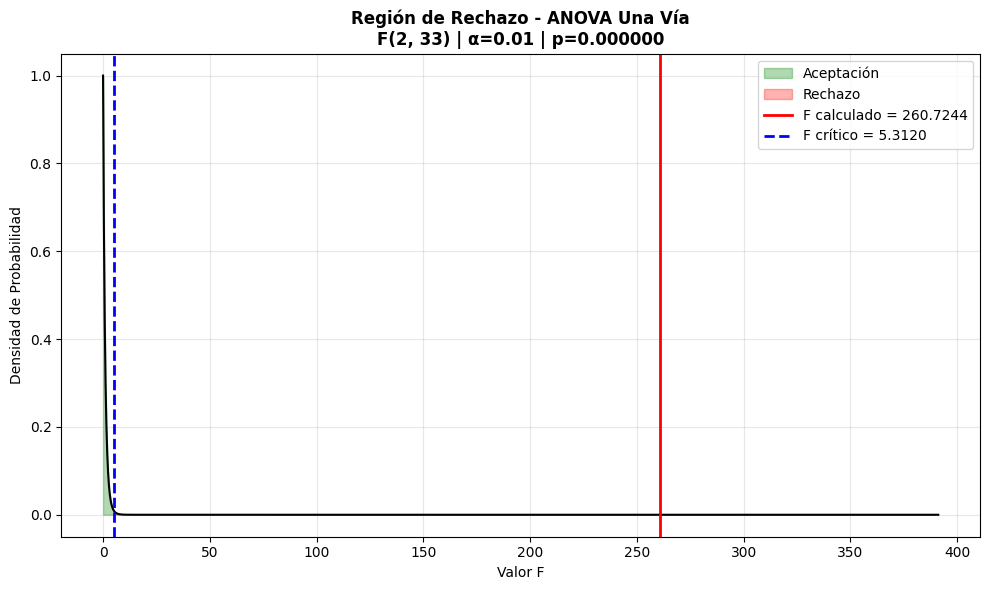

ANÁLISIS COMPLETO FINALIZADO


In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# ============================================================================
# DATOS DEL PROBLEMA
# ============================================================================

metodo_A = [78, 80, 76, 82, 79, 81, 77, 80, 83, 79, 78, 80]
metodo_B = [85, 88, 84, 87, 86, 89, 90, 85, 87, 88, 86, 87]
metodo_C = [70, 72, 68, 71, 69, 73, 70, 72, 71, 70, 69, 71]

data = {
    'Metodo': ['A'] * len(metodo_A) + ['B'] * len(metodo_B) + ['C'] * len(metodo_C),
    'Calificacion': metodo_A + metodo_B + metodo_C
}

df = pd.DataFrame(data)
metodos = df['Metodo'].unique()

# ============================================================================
# CÁLCULOS PRELIMINARES
# ============================================================================

datos = [df[df['Metodo'] == m]['Calificacion'].values for m in metodos]
n_grupos = len(metodos)
n_obs = [len(g) for g in datos]
n_total = sum(n_obs)

media_global = df['Calificacion'].mean()
medias_metodo = df.groupby('Metodo')['Calificacion'].mean().values

print("DATOS ORIGINALES:")
print(df)
print("\nMedias por Método:")
for i, metodo in enumerate(metodos):
    print(f"  {metodo}: {medias_metodo[i]:.4f}")
print(f"Media Global: {media_global:.4f}\n")

# ============================================================================
# ANOVA DE UNA VÍA MANUAL
# ============================================================================

SCT = np.sum((df['Calificacion'] - media_global)**2)
SCB = sum([n_obs[i]*(medias_metodo[i] - media_global)**2 for i in range(n_grupos)])
SCE = SCT - SCB

gl_b = n_grupos - 1
gl_e = n_total - n_grupos
gl_t = n_total - 1

CMb = SCB / gl_b
CMe = SCE / gl_e

F = CMb / CMe
p_value = 1 - stats.f.cdf(F, gl_b, gl_e)
# Using alpha = 0.01 for F_crit
F_crit = stats.f.ppf(1 - 0.01, gl_b, gl_e)

# ============================================================================
# TABLA ANOVA
# ============================================================================

print("TABLA ANOVA DE UNA VÍA")
print("="*80)
print(f"{'Fuente de Variación':<20} {'SC':>12} {'gl':>6} {'CM':>12} {'F':>12} {'Valor-p':>12}")
print("-"*80)
print(f"{'Entre Métodos':<20} {SCB:>12.4f} {gl_b:>6} {CMb:>12.4f} {F:>12.4f} {p_value:>12.6f}")
print(f"{'Error':<20} {SCE:>12.4f} {gl_e:>6} {CMe:>12.4f}")
print(f"{'Total':<20} {SCT:>12.4f} {gl_t:>6}")
print("="*80)

# ============================================================================
# INTERPRETACIÓN ANOVA
# ============================================================================

alpha = 0.01 # Changed alpha to 0.01 as per problem statement
print(f"\nINTERPRETACIÓN ANOVA (α = {alpha}):")
print(f"  F calculado = {F:.4f}")
print(f"  F crítico = {F_crit:.4f}")
print(f"  Valor-p = {p_value:.6f}")

if p_value < alpha:
    print("  ✓ Hay diferencias significativas entre las medias de calificaciones por método de enseñanza.\n")
else:
    print("  ✗ No hay diferencias significativas entre las medias de calificaciones por método de enseñanza.\n")

# ============================================================================
# ANÁLISIS POST-HOC DE TUKEY (HSD)
# ============================================================================

if p_value < alpha:
    print("ANÁLISIS POST-HOC DE TUKEY (HSD):")
    tukey_result = pairwise_tukeyhsd(endog=df['Calificacion'], groups=df['Metodo'], alpha=alpha)
    print(tukey_result)
    print("\nINTERPRETACIÓN TUKEY:")
    print("  Las columnas 'reject' indican si la hipótesis nula (no diferencia entre las medias) se rechaza.")
    print("  'True' significa que hay una diferencia significativa entre los pares de grupos.\n")
else:
    print("No se requiere un análisis Post-Hoc de Tukey, ya que el ANOVA no encontró diferencias significativas.")

# ============================================================================
# GRÁFICO DE REGIÓN DE RECHAZO
# ============================================================================

x = np.linspace(0, max(F, F_crit)*1.5, 1000)
y = stats.f.pdf(x, gl_b, gl_e)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'k-', linewidth=1.5)
plt.fill_between(x[x <= F_crit], y[x <= F_crit], color='green', alpha=0.3, label='Aceptación')
plt.fill_between(x[x >= F_crit], y[x >= F_crit], color='red', alpha=0.3, label='Rechazo')
plt.axvline(F, color='red', linewidth=2, label=f'F calculado = {F:.4f}')
plt.axvline(F_crit, color='blue', linestyle='--', linewidth=2, label=f'F crítico = {F_crit:.4f}')
plt.title(f'Región de Rechazo - ANOVA Una Vía\nF({gl_b}, {gl_e}) | α={alpha} | p={p_value:.6f}', fontsize=12, fontweight='bold')
plt.xlabel('Valor F')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("="*80)
print("ANÁLISIS COMPLETO FINALIZADO")
print("="*80)